In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [13]:
df=pd.read_csv("HousingData.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [15]:
print("Rows and column :", df.shape)

Rows and column : (506, 14)


In [16]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

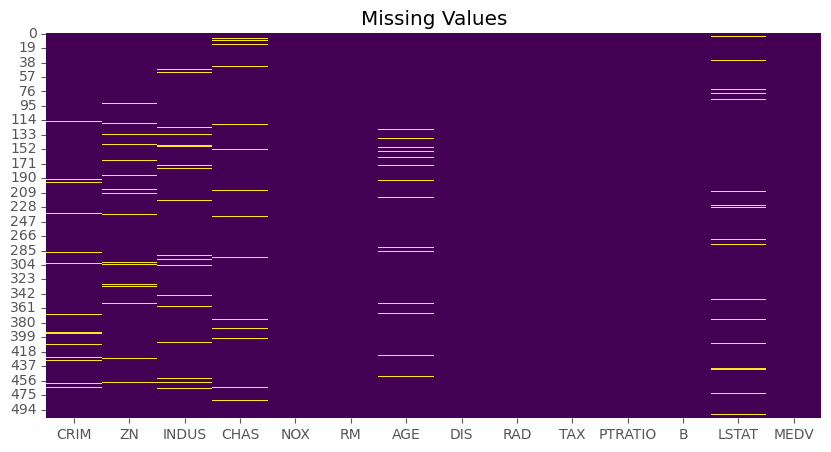

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [19]:
df = df.fillna(df.median(numeric_only=True))

In [20]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [21]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [24]:
df = df.drop_duplicates()

In [26]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.479140,10.768775,11.028893,0.067194,0.554695,6.284634,68.845850,3.795043,9.549407,408.237154,18.455534,356.674032,12.664625,22.532806
std,8.570832,23.025124,6.704679,0.250605,0.115878,0.702617,27.486962,2.105710,8.707259,168.537116,2.164946,91.294864,7.017219,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,2.808720,0.000000,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


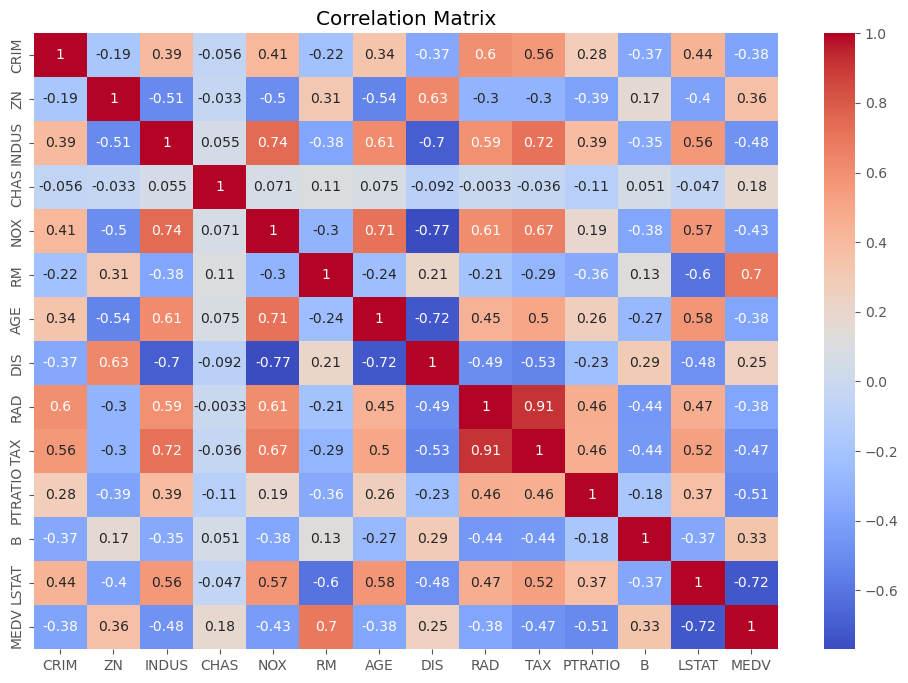

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

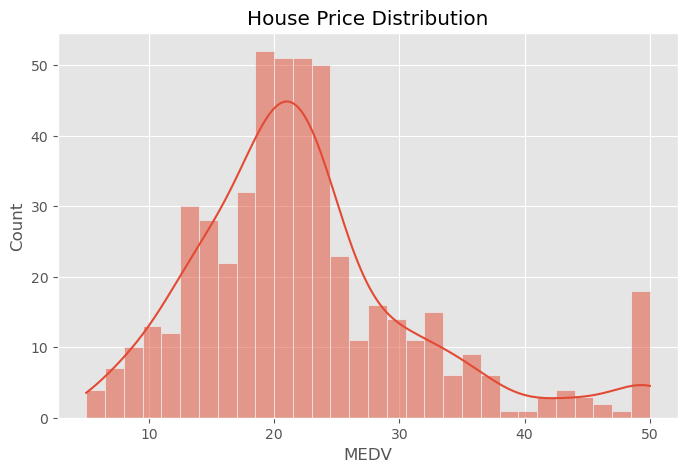

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

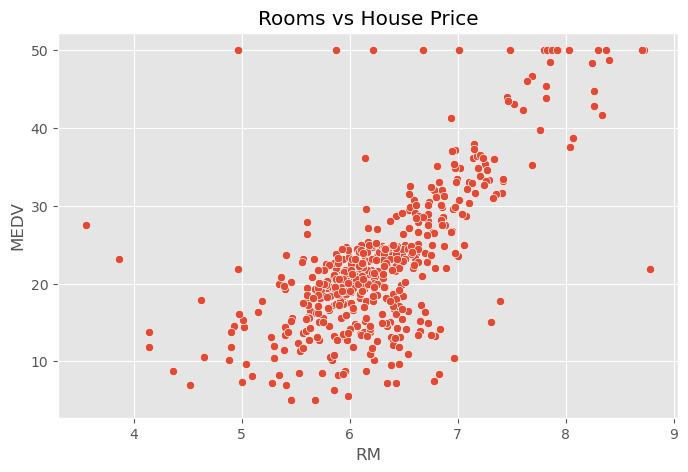

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="RM", y="MEDV", data=df)
plt.title("Rooms vs House Price")
plt.show()

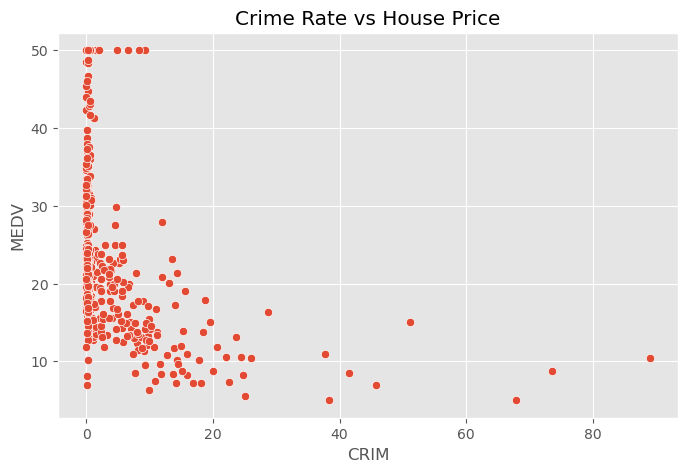

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="CRIM", y="MEDV", data=df)
plt.title("Crime Rate vs House Price")
plt.show()

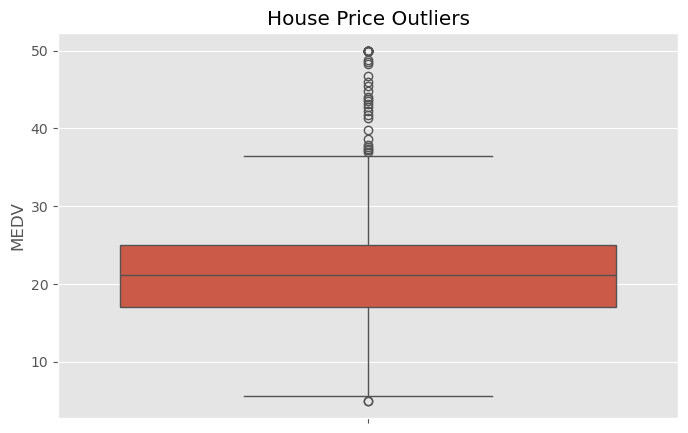

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["MEDV"])
plt.title("House Price Outliers")
plt.show()

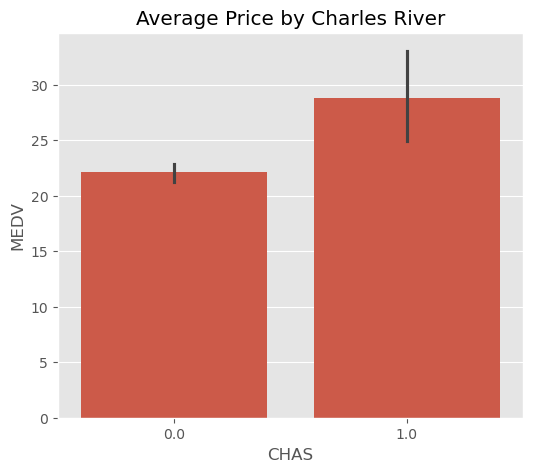

In [32]:
plt.figure(figsize=(6,5))
sns.barplot(x="CHAS", y="MEDV", data=df)
plt.title("Average Price by Charles River")
plt.show()

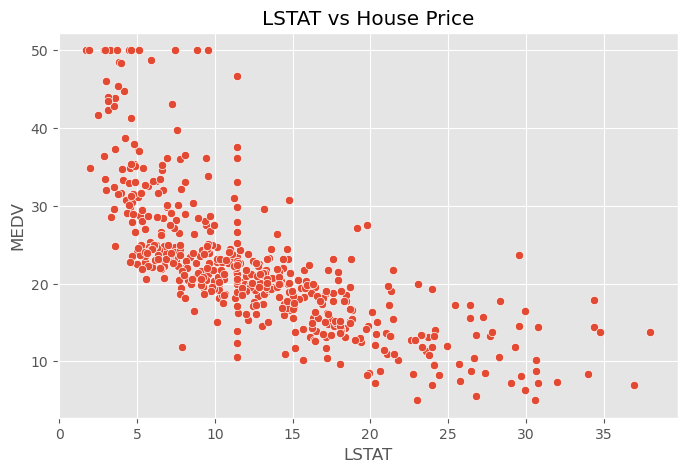

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="LSTAT", y="MEDV", data=df)
plt.title("LSTAT vs House Price")
plt.show()

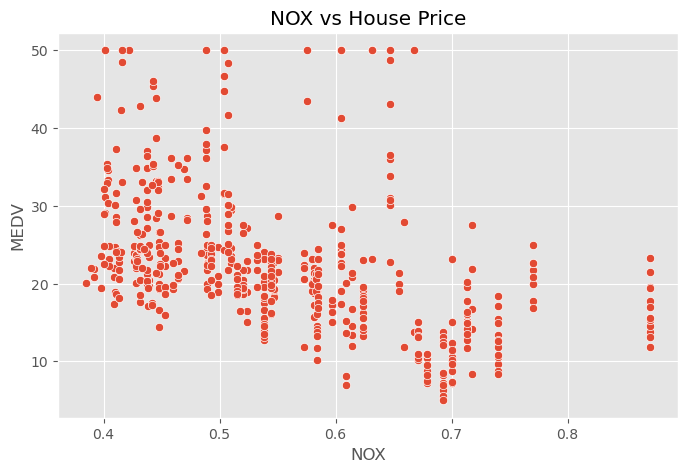

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="NOX", y="MEDV", data=df)
plt.title("NOX vs House Price")
plt.show()

In [35]:
print("Business Insights")
print("-----------------------------")
print("1. Houses with more rooms generally have higher prices.")
print("2. Higher crime rates are associated with lower house prices.")
print("3. Higher LSTAT values generally correspond to lower prices.")
print("4. Missing values were cleaned using median values.")
print("5. Duplicate rows were removed if present.")
print("6. Correlation heatmap shows relationships among all features.")

Business Insights
-----------------------------
1. Houses with more rooms generally have higher prices.
2. Higher crime rates are associated with lower house prices.
3. Higher LSTAT values generally correspond to lower prices.
4. Missing values were cleaned using median values.
5. Duplicate rows were removed if present.
6. Correlation heatmap shows relationships among all features.
